Описан процесс обучения и инференса модели.

Все исходные данные (папка с фото) дополнительно были загружены на собственный Гугл Диск по адресу "/content/drive/MyDrive/Контроль качества семя (Фото)"

# Подготовка датасета

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# Проверка на наличие
from pathlib import Path

root = "/content/drive/MyDrive/Контроль качества семя (Фото)"

classes = ["Отлично","Хорошо","Неплохо","Плохо","Отход"]
exts = {".jpg",".jpeg",".png",".bmp",".tif",".tiff",".webp"}

for cls in classes:
    folder = Path(root)/cls
    exists = folder.exists()
    cnt = sum(1 for p in folder.rglob("*") if p.is_file() and p.suffix.lower() in exts) if exists else 0
    print(f"{cls}: exists={exists}, files={cnt}")

paths, labels = [], []
for cls in classes:
    folder = Path(root)/cls
    if not folder.exists():
        continue
    for p in folder.rglob("*"):
        if p.is_file() and p.suffix.lower() in exts:
            paths.append(str(p))
            labels.append(cls.lower())


Отлично: exists=True, files=65
Хорошо: exists=True, files=267
Неплохо: exists=True, files=201
Плохо: exists=True, files=152
Отход: exists=True, files=4


In [3]:
import numpy as np
from collections import defaultdict, Counter
import csv

# Настройки долей
VAL_SIZE  = 0.15
TEST_SIZE = 0.15
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

# Собираем индексы по классам
# для определения класса берем просто название папок
by_class = defaultdict(list)
for i, y in enumerate(labels):
    by_class[y].append(i)

train_idx, val_idx, test_idx = [], [], []

# формируем список из полных путей до файлов и меток класса
for y, idxs in by_class.items():
    idxs = np.array(idxs)
    rng.shuffle(idxs)
    n = len(idxs)

    # ---- TEST: берём только если у класса >=3 объектов ----
    if n >= 3:
        n_test = int(round(n * TEST_SIZE))
        n_test = max(1, n_test)  # хотя бы 1, раз уж n>=3
    else:
        n_test = 0

    n_test = min(n_test, n - 2)  # оставим минимум 2 на train+val
    test_part = idxs[:n_test]
    remain = idxs[n_test:]
    r = len(remain)

    # ---- VAL: берём аккуратно, чтобы в train не остаться с 0 ----
    if r >= 2:
        rel_val = VAL_SIZE / max(1e-8, (1 - TEST_SIZE))  # доля в остатке
        n_val = int(round(r * rel_val))
        n_val = max(1, n_val)         # хотя бы 1 при r>=2
        n_val = min(n_val, r - 1)     # в train должен остаться ≥1
    else:
        n_val = 0

    val_part = remain[:n_val]
    train_part = remain[n_val:]

    test_idx.extend(test_part.tolist())
    val_idx.extend(val_part.tolist())
    train_idx.extend(train_part.tolist())

# Перемешаем внутри каждого сплита (для равномерности)
rng.shuffle(train_idx); rng.shuffle(val_idx); rng.shuffle(test_idx)

def dump(csv_path, idxs):
    with open(csv_path, "w", newline="", encoding="utf-8") as f:
        w = csv.writer(f)
        w.writerow(["filepath","label"])
        for i in idxs:
            w.writerow([paths[i], labels[i]])

# Сохраним файлы на Диск в ту же папку
root_path = Path(root)
train_csv = root_path/"train.csv"
val_csv   = root_path/"val.csv"
test_csv  = root_path/"test.csv"

dump(str(train_csv), train_idx)
dump(str(val_csv),   val_idx)
dump(str(test_csv),  test_idx)

# Быстрый отчёт по классам
def counts(name, idxs):
    c = Counter(labels[i] for i in idxs)
    print(f"{name} ({len(idxs)}):", dict(sorted(c.items())))

print("Готово. Файлы созданы:")
print(train_csv); print(val_csv); print(test_csv)
counts("train", train_idx)
counts("val",   val_idx)
counts("test",  test_idx)

Готово. Файлы созданы:
/content/drive/MyDrive/Контроль качества семя (Фото)/train.csv
/content/drive/MyDrive/Контроль качества семя (Фото)/val.csv
/content/drive/MyDrive/Контроль качества семя (Фото)/test.csv
train (481): {'неплохо': 141, 'отлично': 45, 'отход': 2, 'плохо': 106, 'хорошо': 187}
val (104): {'неплохо': 30, 'отлично': 10, 'отход': 1, 'плохо': 23, 'хорошо': 40}
test (104): {'неплохо': 30, 'отлично': 10, 'отход': 1, 'плохо': 23, 'хорошо': 40}


Чтобы использовать в CNN,
Напишем класс Dataset, который по пути открывает изображение, применяет трансформации и возвращает (tensor, label).
Обернем его в DataLoader.
Подадим батчи тензоров в модель.


In [4]:
from PIL import Image
import sympy
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

class CSVDataset(Dataset):
    def __init__(self, csv_path, transform=None, class_to_idx=None):
        self.items = list(csv.DictReader(open(csv_path, encoding="utf-8")))
        if class_to_idx is None:
            labels = sorted({row["label"] for row in self.items})
            prefer = ["Отлично","хорошо","неплохо","плохо","отход"]
            ordered = [c for c in prefer if c in labels] + [c for c in labels if c not in prefer]
            self.class_to_idx = {c:i for i,c in enumerate(ordered)}
        else:
            self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        row = self.items[i]
        img = Image.open(row["filepath"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        y = self.class_to_idx[row["label"]]
        return img, y

# Аугментации (очень умеренные) и нормализация под предобученные CNN
tf_train = transforms.Compose([
    transforms.Resize(288),
    transforms.RandomResizedCrop(256, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

tf_val = transforms.Compose([
    transforms.Resize(288),
    transforms.CenterCrop(256),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


#### Дополнение аугментированными изображениями

In [7]:
import random
import os

# Папки и пути
root = Path("/content/drive/MyDrive/Контроль качества семя (Фото)")
train_csv = root / "train.csv"
val_csv   = root / "val.csv"

# Аугментации, которые будут реально генерировать новые изображения
augmentations = transforms.Compose([
    transforms.RandomResizedCrop(256, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
])

# Сколько новых изображений создавать на каждое оригинальное
AUGMENT_MULTIPLIER = 1  # например, создадим 1 дополнительную версию каждого фото

def augment_dataset(csv_path, split_name):
    out_dir = root / f"{split_name}_augmented"
    out_dir.mkdir(exist_ok=True, parents=True)
    new_rows = []

    with open(csv_path, encoding="utf-8") as f:
        reader = csv.DictReader(f)
        rows = list(reader)

    for row in rows:
        img_path = Path(row["filepath"])
        label = row["label"]

        try:
            img = Image.open(img_path).convert("RGB")
        except Exception as e:
            print(f"Ошибка чтения {img_path}: {e}")
            continue

        # Сохраняем оригинальное изображение тоже (опционально)
        new_rows.append({"filepath": str(img_path), "label": label})

        # Генерируем несколько аугментированных копий
        for i in range(AUGMENT_MULTIPLIER):
            aug_img = augmentations(img)
            save_folder = out_dir / label
            save_folder.mkdir(exist_ok=True, parents=True)

            aug_name = f"{img_path.stem}_aug{i}.jpg"
            aug_path = save_folder / aug_name
            aug_img.save(aug_path)
            new_rows.append({"filepath": str(aug_path), "label": label})

    # Создаём новый CSV
    aug_csv = root / f"{split_name}_augmented.csv"
    with open(aug_csv, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=["filepath", "label"])
        writer.writeheader()
        writer.writerows(new_rows)

    print(f"{split_name}: сохранено {len(new_rows)} изображений в {aug_csv}")
    return aug_csv


# ===== Запуск =====
train_aug_csv = augment_dataset(train_csv, "train")
val_aug_csv   = augment_dataset(val_csv, "val")

print("Готово!")
print("train_aug_csv:", train_aug_csv)
print("val_aug_csv:", val_aug_csv)


train: сохранено 962 изображений в /content/drive/MyDrive/Контроль качества семя (Фото)/train_augmented.csv
val: сохранено 208 изображений в /content/drive/MyDrive/Контроль качества семя (Фото)/val_augmented.csv
Готово!
train_aug_csv: /content/drive/MyDrive/Контроль качества семя (Фото)/train_augmented.csv
val_aug_csv: /content/drive/MyDrive/Контроль качества семя (Фото)/val_augmented.csv


In [32]:
# То же самое для тестового набора
root = Path("/content/drive/MyDrive/Контроль качества семя (Фото)")
test_csv = root / "test.csv"

# Аугментации, которые будут реально генерировать новые изображения
augmentations = transforms.Compose([
    transforms.RandomResizedCrop(256, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
])

# Сколько новых изображений создавать на каждое оригинальное
AUGMENT_MULTIPLIER = 1  # например, создадим 1 дополнительных версии каждого фото

# ===== Запуск =====
test_aug_csv = augment_dataset(test_csv, "test")

print("Готово!")
print("test_aug_csv:", test_aug_csv)


test: сохранено 208 изображений в /content/drive/MyDrive/Контроль качества семя (Фото)/test_augmented.csv
Готово!
test_aug_csv: /content/drive/MyDrive/Контроль качества семя (Фото)/test_augmented.csv


In [8]:
root = "/content/drive/MyDrive/Контроль качества семя (Фото)"
train_csv = str(Path(root) / "train_augmented.csv")
val_csv   = str(Path(root) / "val_augmented.csv")

# Фиксируем интуитивный порядок классов
# от худшего к лучшему
class_names = ["отход", "плохо", "неплохо", "хорошо", "отлично"]
class_to_idx = {cls: i for i, cls in enumerate(class_names)}
print("Фиксированный порядок классов → индексы:", class_to_idx)

# Теперь этот порядок используется при создании датасетов
train_ds = CSVDataset(train_csv, transform=tf_train, class_to_idx=class_to_idx)
val_ds   = CSVDataset(val_csv,   transform=tf_val,   class_to_idx=class_to_idx)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

# Тест тоже должен использовать тот же mapping
test_csv = str(Path(root) / "test_augmented.csv")
test_ds = CSVDataset(test_csv, transform=tf_val, class_to_idx=class_to_idx)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

print("Размеры:", len(train_ds), len(val_ds), len(test_ds))


Фиксированный порядок классов → индексы: {'отход': 0, 'плохо': 1, 'неплохо': 2, 'хорошо': 3, 'отлично': 4}
Размеры: 962 208 104


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [9]:
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
from torch.utils.data import Subset

# Сколько изображений оставить для обучения (стратифицированно)
N_TRAIN_LIMIT = 1000  # при необходимости поменяй

# class_to_idx берём из train.csv, порядок фиксируем
_tmp = CSVDataset(train_csv)
# Фиксируем интуитивный порядок классов
# от худшего к лучшему
class_names = ["отход", "плохо", "неплохо", "хорошо", "отлично"]
class_to_idx = {cls: i for i, cls in enumerate(class_names)}
print("Фиксированный порядок классов → индексы:", class_to_idx)

# Считаем списки X (пути) и y (строковые метки) из train.csv
X_all, y_all = [], []
with open(train_csv, encoding="utf-8") as f:
    rdr = csv.DictReader(f)
    for row in rdr:
        X_all.append(row["filepath"])
        y_all.append(row["label"])

n_total = len(X_all)
print(f"Всего train изображений: {n_total}")

# Если данных больше лимита — делаем стратифицированный сабсэмпл
if n_total > N_TRAIN_LIMIT:
    sss = StratifiedShuffleSplit(n_splits=1, train_size=N_TRAIN_LIMIT, random_state=42)
    idx_array = np.arange(n_total)
    train_idx, _ = next(sss.split(idx_array, y_all))
    selected_idx = np.sort(train_idx)
    print(f"Оставляем для обучения: {selected_idx.size} изображений (стратифицировано)")
else:
    selected_idx = np.arange(n_total)
    print(f"Данных ≤ {N_TRAIN_LIMIT}; берём всё: {selected_idx.size}")

# Собираем датасеты
full_train_ds = CSVDataset(train_csv, transform=tf_train, class_to_idx=class_to_idx)
train_ds = Subset(full_train_ds, selected_idx.tolist())

# Валидацию НЕ ограничиваем (правильная переменная: val_csv)
val_ds = CSVDataset(val_csv, transform=tf_val, class_to_idx=class_to_idx)

# (не обязательный, но удобный шаг) пересоздадим лоадеры под обновлённый train_ds
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=4, pin_memory=True)


Фиксированный порядок классов → индексы: {'отход': 0, 'плохо': 1, 'неплохо': 2, 'хорошо': 3, 'отлично': 4}
Всего train изображений: 962
Данных ≤ 1000; берём всё: 962


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [10]:
imgs, ys = next(iter(train_loader))
print("batch imgs:", imgs.shape)   # [B, 3, 256, 256]
print("batch labels:", ys.shape)   # [B]
print("dtype:", imgs.dtype, "min/max:", imgs.min().item(), imgs.max().item())

batch imgs: torch.Size([32, 3, 256, 256])
batch labels: torch.Size([32])
dtype: torch.float32 min/max: -2.1179039478302 2.640000104904175


# Обучение модели

## Загрузка предобученной ResNet50

In [11]:
# ========= 1) Устройство и число классов =========
import torch
from torchvision import models
import torch.nn as nn
from collections import Counter
import csv

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(class_to_idx)
num_classes # должен быть 5

5

In [12]:
# ========= 2) Загружаем предобученную ResNet50 =========
# Пытаемся через новый API (weights=...), если нет — откатываемся к pretrained=True
try:
    weights = models.ResNet50_Weights.DEFAULT
    backbone = models.resnet50(weights=weights)
except Exception:
    backbone = models.resnet50(pretrained=True)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 135MB/s]


In [13]:
# ========= 3) «Замораживаем» все слои-экстрактор =========
for p in backbone.parameters():
    p.requires_grad = False

# (опционально) фиксируем BatchNorm-слои бэкбона в режиме eval,
# чтобы их статистики не обновлялись при обучении головы
def _set_bn_eval(m):
    if isinstance(m, nn.BatchNorm2d):
        m.eval()
backbone.apply(_set_bn_eval)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

▌Зачем это нужно

•  Скорость и стабильность на малом датасете. У нас ~700 фото: обучать всю сеть рискованно — быстро переобучимся и будем долго считать. Заморозка оставляет только обучение новой «головы», что быстро даёт сильный бейзлайн.

•  Снижение потребления памяти. Нет градиентов у бэкбона → больше батч либо меньше ООМ.

•  Стабильные признаки. Предобученная ResNet уже извлекает текстуры/дефекты/формы; «голова» учится лишь разводить 5 наших классов.

In [14]:
# ========= 4) Меняем классификатор (голову) под наши 5 классов =========
in_features = backbone.fc.in_features
backbone.fc = nn.Linear(in_features, num_classes)  # новая «голова» под наши классы

model = backbone.to(device)

In [15]:
# ========= 5) Функция потерь (с учетом возможного дисбаланса) =========
# Считаем частоты по train.csv в порядке class_to_idx
counter = Counter()
with open(train_csv, encoding="utf-8") as f:
    for row in csv.DictReader(f):
        counter[row["label"]] += 1

# Вес класса: n_samples / (num_classes * count_c) — стандартный инверс по частоте
total = sum(counter.values())
weights = []
# class_to_idx задает порядок классов; соблюдаем его
for cls_name, _idx in sorted(class_to_idx.items(), key=lambda x: x[1]):
    cnt = max(1, counter.get(cls_name, 0))
    weights.append(total / (num_classes * cnt))

class_weights = torch.tensor(weights, dtype=torch.float32, device=device)
criterion = nn.CrossEntropyLoss(weight=class_weights)  # если дисбаланса почти нет — можно убрать weight


In [16]:
# ========= 6) Оптимизатор (только голова) =========
# Обучаем только новые параметры классификатора
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3, weight_decay=1e-4)

In [17]:
# ========= 7) Быстрый sanity-check формы выходов =========
model.eval()
with torch.no_grad():
    xb, yb = next(iter(train_loader))     # берем один батч
    xb = xb.to(device)
    logits = model(xb)                    # [B, num_classes]
    print("Логиты формы:", tuple(logits.shape))  # должно быть (batch_size, 5)

print("Trainable params в голове:", sum(p.numel() for p in model.fc.parameters() if p.requires_grad))
print("Всего trainable params в модели:", sum(p.numel() for p in model.parameters() if p.requires_grad))
print("Готово: бэкбон «заморожен», голова под 5 классов, loss/optimizer настроены.")

Логиты формы: (32, 5)
Trainable params в голове: 10245
Всего trainable params в модели: 10245
Готово: бэкбон «заморожен», голова под 5 классов, loss/optimizer настроены.


Это завершает первый этап: предобученная ResNet50 загружена, бэкбон «заморожен», голова заменена, заданы criterion и optimizer (только для головы), и есть sanity-check на форму логитов

## Дообучаем последний слой модели

In [18]:
# =========================
# 2) Тренируем ТОЛЬКО "голову"
# =========================
import torch
import torch.nn as nn
from torch.cuda.amp import autocast, GradScaler
from pathlib import Path
from copy import deepcopy
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import numpy as np

# --- Папка для артефактов и путь для лучшей модели
artifacts_dir = Path(root) / "artifacts"
artifacts_dir.mkdir(parents=True, exist_ok=True)
best_ckpt_path = artifacts_dir / "resnet50_head_only_best.pth"

# --- AMP (ускорение и экономия памяти на GPU)
use_amp = torch.cuda.is_available()
scaler = GradScaler(enabled=use_amp)

# --- На всякий случай: функция, чтобы BatchNorm оставался в eval, когда тренируем ТОЛЬКО голову
try:
    _set_bn_eval
except NameError:
    def _set_bn_eval(m):
        if isinstance(m, nn.BatchNorm2d):
            m.eval()

/tmp/ipython-input-544174649.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=use_amp)


In [19]:
def evaluate(model, loader, criterion):
    """Валидация: считаем средний loss, accuracy и macro-F1."""
    model.eval()
    losses = []
    all_true, all_pred = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            with autocast(enabled=use_amp):
                logits = model(xb)
                loss = criterion(logits, yb)

            losses.append(loss.item())
            pred = logits.argmax(dim=1)
            all_true.append(yb.detach().cpu().numpy())
            all_pred.append(pred.detach().cpu().numpy())

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)

    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    return float(np.mean(losses)), acc, f1m, y_true, y_pred

def train_head_only(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=10,
    patience=3,             # ранняя остановка по val macro-F1
    print_every=1
):
    best_f1 = -1.0
    best_state = None
    no_improve = 0

    for epoch in range(1, epochs + 1):
        # --- Тренировка одной эпохи
        model.train()
        # Важно: фиксируем BN в eval, чтобы не "плыли" статистики у замороженного бэкбона
        model.apply(_set_bn_eval)

        running_loss = 0.0
        n_batches = 0

        for xb, yb in train_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with autocast(enabled=use_amp):
                logits = model(xb)             # [B, num_classes]
                loss = criterion(logits, yb)    # CE-loss

            # AMP backward + step
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()
            n_batches += 1

        train_loss = running_loss / max(1, n_batches)

        # --- Валидация по концу эпохи
        val_loss, val_acc, val_f1, y_true, y_pred = evaluate(model, val_loader, criterion)

        if epoch % print_every == 0:
            print(f"[Эпоха {epoch:02d}] "
                  f"train_loss={train_loss:.4f} | "
                  f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_f1(macro)={val_f1:.4f}")

        # --- Ранняя остановка по macro-F1
        if val_f1 > best_f1 + 1e-5:
            best_f1 = val_f1
            best_state = deepcopy(model.state_dict())
            torch.save(best_state, best_ckpt_path)
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Ранняя остановка: без улучшений {patience} эпох(и). Лучший val_f1={best_f1:.4f}")
                break

    # --- Загружаем лучшую модель и финально печатаем отчёт по валидации
    if best_state is not None:
        model.load_state_dict(best_state)

    val_loss, val_acc, val_f1, y_true, y_pred = evaluate(model, val_loader, criterion)
    print("\nЛучшие итоговые метрики на валидации:")
    print(f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_f1(macro)={val_f1:.4f}")

    # Красивый отчёт по классам
    idx_to_class = {v: k for k, v in class_to_idx.items()}
    target_names = [idx_to_class[i] for i in range(len(idx_to_class))]
    print("\nClassification report (валидация):")
    print(classification_report(y_true, y_pred, target_names=target_names, digits=4))

    # Матрица ошибок — полезно глазами увидеть, где путается
    print("Confusion matrix (валидация):")
    print(confusion_matrix(y_true, y_pred))

    return model


In [20]:
# ===== Запуск обучения головы =====
trained_model = train_head_only(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=10,      # можно 8–12
    patience=3      # остановимся, если 3 эпохи нет роста macro-F1
)

/tmp/ipython-input-1435089838.py:57: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
/tmp/ipython-input-1435089838.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):


[Эпоха 01] train_loss=1.2774 | val_loss=1.1471 | val_acc=0.6250 | val_f1(macro)=0.4751


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/tmp/ipython-input-1435089838.py:57: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
/tmp/ipython-input-1435089838.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):


[Эпоха 02] train_loss=0.8041 | val_loss=0.9083 | val_acc=0.6538 | val_f1(macro)=0.4920


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/tmp/ipython-input-1435089838.py:57: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
/tmp/ipython-input-1435089838.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):


...

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/tmp/ipython-input-1435089838.py:57: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
/tmp/ipython-input-1435089838.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):


[Эпоха 10] train_loss=0.2966 | val_loss=0.5890 | val_acc=0.7837 | val_f1(macro)=0.6308


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/tmp/ipython-input-1435089838.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):



Лучшие итоговые метрики на валидации:
val_loss=0.5890 | val_acc=0.7837 | val_f1(macro)=0.6308

Classification report (валидация):
              precision    recall  f1-score   support

       отход     0.0000    0.0000    0.0000         2
       плохо     0.9412    0.6957    0.8000        46
     неплохо     0.6939    0.5667    0.6239        60
      хорошо     0.7778    0.9625    0.8603        80
     отлично     0.7692    1.0000    0.8696        20

    accuracy                         0.7837       208
   macro avg     0.6364    0.6450    0.6308       208
weighted avg     0.7814    0.7837    0.7714       208

Confusion matrix (валидация):
[[ 0  2  0  0  0]
 [ 0 32 12  2  0]
 [ 0  0 34 20  6]
 [ 0  0  3 77  0]
 [ 0  0  0  0 20]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Хороший старт для “только головы”.**

Accuracy 0.78 — нормальный бейзлайн на замороженном бэкбоне: сеть уже что-то «видит».

Macro-F1 0.63 — проседает из-за редких классов, прежде всего «отход»: во валидации всего 1 пример

## Fine-tuning



1. Размораживает последний блок layer4 у ResNet50 (бэкбон остаётся в остальном заморожен).
2. Пересобирает оптимизатор с дифференциальным LR: голова — LR побольше, layer4 — в 5–10 раз меньше.
3. Вводит класс-сбалансированную выборку через WeightedRandomSampler (учитывает **дисбаланс**).


In [21]:
# ============================================
# 3) FINE-TUNING: размораживаем layer4 + балансный сэмплер
# ============================================
import torch
import torch.nn as nn
from torch.utils.data import WeightedRandomSampler, Subset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from pathlib import Path
from copy import deepcopy
import numpy as np
import csv

# --- Папка артефактов и путь до чекпойнта fine-tune
artifacts_dir = Path(root) / "artifacts"
artifacts_dir.mkdir(parents=True, exist_ok=True)
best_finetune_ckpt = artifacts_dir / "resnet50_finetune_layer4_best.pth"


In [22]:
# ===== 3.1 BALANCED SAMPLER (учитываем дисбаланс классов) =====
def make_weighted_sampler_for_train_csv(train_csv_path, class_to_idx, selected_idx=None):
    """
    Строим веса сэмплов как 1/freq(class).
    Если передан selected_idx (Subset), учитываем только эти индексы.
    Возвращаем weights_selected (list) в порядке выборки и num_samples.
    """
    # читаем весь train.csv и строим список меток по порядку строк
    y_all = []
    with open(train_csv_path, encoding="utf-8") as f:
        for row in csv.DictReader(f):
            y_all.append(class_to_idx[row["label"]])  # в csv метки в нижнем регистре

    # частоты классов на полном train.csv
    counts = np.bincount(np.array(y_all), minlength=len(class_to_idx))
    counts[counts == 0] = 1  # защита от деления на 0
    class_weight = 1.0 / counts  # инверс частот

    # если у нас Subset(train) — берём только выбранные индексы
    if selected_idx is None:
        selected_idx = list(range(len(y_all)))

    # веса образцов в порядке выбранных индексов
    weights_selected = [float(class_weight[y_all[i]]) for i in selected_idx]
    num_samples = len(weights_selected)
    return weights_selected, num_samples

# Если раньше собирали train_ds как Subset(..., selected_idx), достанем индексы.
subset_idx = None
if isinstance(train_ds, Subset):
    subset_idx = list(train_ds.indices)

# Строим балансный сэмплер и пересоздаём train_loader (shuffle=False при sampler)
weights_selected, num_samples = make_weighted_sampler_for_train_csv(train_csv, class_to_idx, selected_idx=subset_idx)
sampler = WeightedRandomSampler(weights_selected, num_samples=num_samples, replacement=True)

# batch_size как раньше; num_workers/pin_memory сохраняем
train_loader = DataLoader(train_ds, batch_size=32, sampler=sampler, num_workers=4, pin_memory=True)

print("Сбалансированный сэмплер активирован:",
      f"num_samples={num_samples}, примеры редких классов будут попадать чаще.")


Сбалансированный сэмплер активирован: num_samples=962, примеры редких классов будут попадать чаще.


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [23]:
# ===== 3.2 РАЗМОРОЖКА LAYER4 =====
def unfreeze_last_block(model, train_bn=False):
    """
    Размораживаем последний блок (layer4) ResNet50.
    train_bn=False — BatchNorm остаётся замороженным (eval, без обновления running stats и без градиентов).
    """
    # 1) Сначала убедимся, что всё остальное заморожено
    for p in model.parameters():
        p.requires_grad = False

    # 2) Разморозим параметры layer4
    for m in model.layer4.modules():
        if isinstance(m, nn.BatchNorm2d):
            if train_bn:
                # Позволяем обучать масштаб/смещение BN, но это рискованно при маленьком батче
                for p in m.parameters():
                    p.requires_grad = True
            else:
                # BN фиксируем полностью
                for p in m.parameters():
                    p.requires_grad = False
        else:
            # Conv/Linear в layer4 учим
            for p in m.parameters():
                p.requires_grad = True

    # 3) Голова (fc) — обязательно обучаем
    for p in model.fc.parameters():
        p.requires_grad = True

    return model

model = unfreeze_last_block(model, train_bn=False)

In [24]:

# ===== 3.3 ОПТИМИЗАТОР С ДИФФЕРЕНЦИАЛЬНЫМИ LR =====
# Группа 1: голова (fc) — больший LR
# Группа 2: layer4 — меньший LR
lr_head = 1e-3
lr_backbone = 1e-4  # в 10 раз меньше головы
weight_decay = 1e-4

head_params = [p for p in model.fc.parameters() if p.requires_grad]
layer4_params = [p for p in model.layer4.parameters() if p.requires_grad]

optimizer = torch.optim.AdamW(
    [
        {"params": head_params, "lr": lr_head},
        {"params": layer4_params, "lr": lr_backbone},
    ],
    weight_decay=weight_decay
)

# AMP для ускорения
use_amp = torch.cuda.is_available()
scaler = GradScaler(enabled=use_amp)


/tmp/ipython-input-1216047110.py:21: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=use_amp)


In [25]:
# Функция, чтобы держать BN в eval на всём бэкбоне (включая layer4, если train_bn=False)
def _set_frozen_bn_eval(m):
    if isinstance(m, nn.BatchNorm2d):
        m.eval()

In [26]:
# ===== 3.4 ТРЕНИРОВКА FINE-TUNE (похожа на прошлую, но с новым оптимизатором) =====
def evaluate(model, loader, criterion):
    model.eval()
    losses = []
    all_true, all_pred = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            with autocast(enabled=use_amp):
                logits = model(xb)
                loss = criterion(logits, yb)
            losses.append(loss.item())
            all_true.append(yb.detach().cpu().numpy())
            all_pred.append(logits.argmax(1).detach().cpu().numpy())
    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    return float(np.mean(losses)), acc, f1m, y_true, y_pred

def train_finetune(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=10,
    patience=3,          # по macro-F1
    print_every=1
):
    best_f1 = -1.0
    best_state = None
    no_improve = 0

    # Небольшой LR-scheduler (по эпохам) — сглаживает обучение
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr_backbone * 0.1)

    for epoch in range(1, epochs + 1):
        model.train()
        # ВАЖНО: фиксируем BN в eval (особенно при маленьком батче)
        model.apply(_set_frozen_bn_eval)

        running_loss = 0.0
        n_batches = 0

        for xb, yb in train_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with autocast(enabled=use_amp):
                logits = model(xb)
                loss = criterion(logits, yb)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()
            n_batches += 1

        train_loss = running_loss / max(1, n_batches)

        # валидация
        val_loss, val_acc, val_f1, y_true, y_pred = evaluate(model, val_loader, criterion)

        if epoch % print_every == 0:
            # текущие LR для контроля
            lrs = [g["lr"] for g in optimizer.param_groups]
            print(f"[FT Эпоха {epoch:02d}] train_loss={train_loss:.4f} | "
                  f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_f1={val_f1:.4f} | lrs={lrs}")

        # ранняя остановка по macro-F1
        if val_f1 > best_f1 + 1e-5:
            best_f1 = val_f1
            best_state = deepcopy(model.state_dict())
            torch.save(best_state, best_finetune_ckpt)
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Ранняя остановка (fine-tune): {patience} эпох(и) без улучшений. Лучший val_f1={best_f1:.4f}")
                break

        scheduler.step()

    # загрузим лучший чекпойнт и напечатаем финальный отчёт
    if best_state is not None:
        model.load_state_dict(best_state)

    val_loss, val_acc, val_f1, y_true, y_pred = evaluate(model, val_loader, criterion)
    print("\n[Fine-Tune] Итог по валидации:")
    print(f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_f1(macro)={val_f1:.4f}")

    idx_to_class = {v: k for k, v in class_to_idx.items()}
    target_names = [idx_to_class[i] for i in range(len(idx_to_class))]

    print("\nClassification report (валидация):")
    print(classification_report(y_true, y_pred, target_names=target_names, digits=4))

    print("Confusion matrix (валидация):")
    print(confusion_matrix(y_true, y_pred))

    return model


In [27]:
# ===== Запуск fine-tuning =====
finetuned_model = train_finetune(
    model=model,
    train_loader=train_loader,  # уже с WeightedRandomSampler
    val_loader=val_loader,
    criterion=criterion,        # тот же CE с class_weights
    optimizer=optimizer,
    epochs=10,                  # 8–12 обычно достаточно
    patience=3
)

/tmp/ipython-input-1142001057.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
/tmp/ipython-input-1142001057.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):


[FT Эпоха 01] train_loss=0.0208 | val_loss=0.4827 | val_acc=0.7933 | val_f1=0.6673 | lrs=[0.001, 0.0001]


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/tmp/ipython-input-1142001057.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
/tmp/ipython-input-1142001057.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):


[FT Эпоха 02] train_loss=0.0073 | val_loss=1.5528 | val_acc=0.6538 | val_f1=0.5033 | lrs=[0.0009757729755661011, 9.779754323328192e-05]


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/tmp/ipython-input-1142001057.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
/tmp/ipython-input-1142001057.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):


...

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/tmp/ipython-input-1142001057.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
/tmp/ipython-input-1142001057.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):


[FT Эпоха 04] train_loss=0.0353 | val_loss=0.4811 | val_acc=0.7885 | val_f1=0.6588 | lrs=[0.0007959536998847742, 8.14503363531613e-05]
Ранняя остановка (fine-tune): 3 эпох(и) без улучшений. Лучший val_f1=0.6673


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/tmp/ipython-input-1142001057.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):



[Fine-Tune] Итог по валидации:
val_loss=0.4827 | val_acc=0.7933 | val_f1(macro)=0.6673

Classification report (валидация):
              precision    recall  f1-score   support

       отход     0.0000    0.0000    0.0000         2
       плохо     0.9500    0.8261    0.8837        46
     неплохо     0.6418    0.7167    0.6772        60
      хорошо     0.8000    0.8000    0.8000        80
     отлично     0.9524    1.0000    0.9756        20

    accuracy                         0.7933       208
   macro avg     0.6688    0.6686    0.6673       208
weighted avg     0.7945    0.7933    0.7923       208

Confusion matrix (валидация):
[[ 0  2  0  0  0]
 [ 0 38  8  0  0]
 [ 0  0 43 16  1]
 [ 0  0 16 64  0]
 [ 0  0  0  0 20]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Уже намного лучше:
val_loss=0.4827 | val_acc=0.7933 | val_f1(macro)=0.6673

# Финальное дообучение и оценка

In [33]:
# ============================================
# ФИНАЛИЗАЦИЯ ОБУЧЕНИЯ: тест, сохранение, экспорт
# ============================================
import os, json, time
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# --- 0) Пути к чекпойнтам (берём fine-tune, если есть; иначе head-only)
artifacts_dir = Path(root) / "artifacts"
ft_ckpt   = artifacts_dir / "resnet50_finetune_layer4_best.pth"
head_ckpt = artifacts_dir / "resnet50_head_only_best.pth"
ckpt_path = ft_ckpt if ft_ckpt.exists() else head_ckpt
assert ckpt_path.exists(), "Не найден лучший чекпойнт. Сначала обучите модель."
print(f"Используем чекпойнт: {ckpt_path.name}")

# --- 1) Готовим тестовый датасет/лоадер
# Ожидаем test_augmented.csv в той же структуре, что и train/val. Если его нет — используем val.csv как тест (на ваш риск).
test_csv_path = Path(root) / "test_augmented.csv"
if not test_csv_path.exists():
    print("ВНИМАНИЕ: test_augmented.csv не найден → используем val_csv как тестовый сет.")
    test_csv_path = Path(val_csv)

test_ds = CSVDataset(str(test_csv_path), transform=tf_val, class_to_idx=class_to_idx)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

# --- 2) Загружаем лучший чекпойнт и переводим в eval
model.load_state_dict(torch.load(ckpt_path, map_location=device))
model.to(device).eval()

# --- 3) Итоговая оценка на test_augmented.csv: loss, accuracy, macro-F1 + отчёт и матрица ошибок
@torch.no_grad()
def evaluate_final(model, loader, criterion=None):
    losses = []
    all_true, all_pred = [], []
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        logits = model(xb)
        if criterion is not None:
            loss = criterion(logits, yb).item()
            losses.append(loss)
        pred = logits.argmax(1)
        all_true.append(yb.detach().cpu().numpy())
        all_pred.append(pred.detach().cpu().numpy())
    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)
    metrics = {
        "acc": float(accuracy_score(y_true, y_pred)),
        "f1_macro": float(f1_score(y_true, y_pred, average="macro")),
    }
    return metrics, y_true, y_pred, (np.mean(losses) if losses else None)

final_metrics, y_true, y_pred, test_loss = evaluate_final(model, test_loader, criterion)
print("\n=== Итог на TEST ===")
print(f"test_loss={test_loss:.4f}" if test_loss is not None else "test_loss=N/A")
print(f"test_acc={final_metrics['acc']:.4f} | test_f1(macro)={final_metrics['f1_macro']:.4f}")

# Подробный отчёт по классам
idx_to_class = {v: k for k, v in class_to_idx.items()}
target_names = [idx_to_class[i] for i in range(len(idx_to_class))]
print("\nClassification report (test):")
print(classification_report(y_true, y_pred, target_names=target_names, digits=4))

# Матрица ошибок + сохранение картинки
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix (test)")
plt.colorbar()
tick_marks = np.arange(len(target_names))
plt.xticks(tick_marks, target_names, rotation=45, ha="right")
plt.yticks(tick_marks, target_names)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout()
cm_path = artifacts_dir / "confusion_matrix_test.png"
plt.savefig(cm_path, dpi=150)
plt.close()
print(f"Матрица ошибок сохранена: {cm_path}")


Используем чекпойнт: resnet50_finetune_layer4_best.pth


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(



=== Итог на TEST ===
test_loss=0.3125
test_acc=0.8077 | test_f1(macro)=0.8777

Classification report (test):
              precision    recall  f1-score   support

       отход     1.0000    1.0000    1.0000         2
       плохо     0.9375    0.9783    0.9574        46
     неплохо     0.6716    0.7500    0.7087        60
      хорошо     0.8000    0.7000    0.7467        80
     отлично     0.9524    1.0000    0.9756        20

    accuracy                         0.8077       208
   macro avg     0.8723    0.8857    0.8777       208
weighted avg     0.8100    0.8077    0.8068       208

Матрица ошибок сохранена: /content/drive/MyDrive/Контроль качества семя (Фото)/artifacts/confusion_matrix_test.png


**Это успех!**

Все метрики больше 80%:
test_loss=0.3125
test_acc=0.8077 | test_f1(macro)=0.8777

# Сохранение модели

In [34]:
# ===== Сохраняем итоговую модель =====
torch.save(finetuned_model.state_dict(), "finetuned_model.pth")
print("Модель сохранена в файл 'finetuned_model.pth'")


Модель сохранена в файл 'finetuned_model.pth'


In [35]:
!pip install onnx

In [36]:
import torch

# Переносим модель на CPU
finetuned_model.to("cpu")
finetuned_model.eval()

# Пример входных данных (на CPU!)
dummy_input = torch.randn(1, 3, 224, 224, device="cpu")

onnx_path = "finetuned_model.onnx"

torch.onnx.export(
    finetuned_model,
    dummy_input,
    onnx_path,
    export_params=True,
    opset_version=11,
    do_constant_folding=True,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}
)

print(f"Модель экспортирована в ONNX: {onnx_path}")


/tmp/ipython-input-68610854.py:12: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(


Модель экспортирована в ONNX: finetuned_model.onnx


# Визуализация

Рассмотрим как происходит аугментация, т.е. что видит сама модель

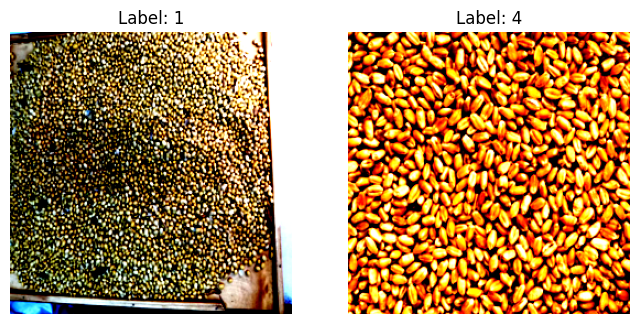

In [39]:
import matplotlib.pyplot as plt
import torch
import random

# train_ds — Subset, нужно получить доступ к dataset через .dataset
dataset = train_ds.dataset
indices = train_ds.indices  # индексы внутри исходного датасета

# Выберем 2 случайных примера
sample_indices = random.sample(indices, 2)

plt.figure(figsize=(8, 4))

for i, idx in enumerate(sample_indices):
    img, label = dataset[idx]  # предполагаем, что dataset возвращает (img, label)

    # Если img — тензор (C,H,W), нужно преобразовать в (H,W,C)
    if isinstance(img, torch.Tensor):
        img = img.permute(1, 2, 0).numpy()

    plt.subplot(1, 2, i+1)
    plt.imshow(img)
    plt.title(f"Label: {label}")
    plt.axis("off")

plt.show()


Дообучение последнего слоя предобученной модели: val_loss=0.5890 | val_acc=0.7837 | val_f1(macro)=0.6308

Fine-tuning: val_loss=0.4827 | val_acc=0.7933 | val_f1(macro)=0.6673

Final test score: test_loss=0.3125 test_acc=0.8077 | test_f1(macro)=0.8777

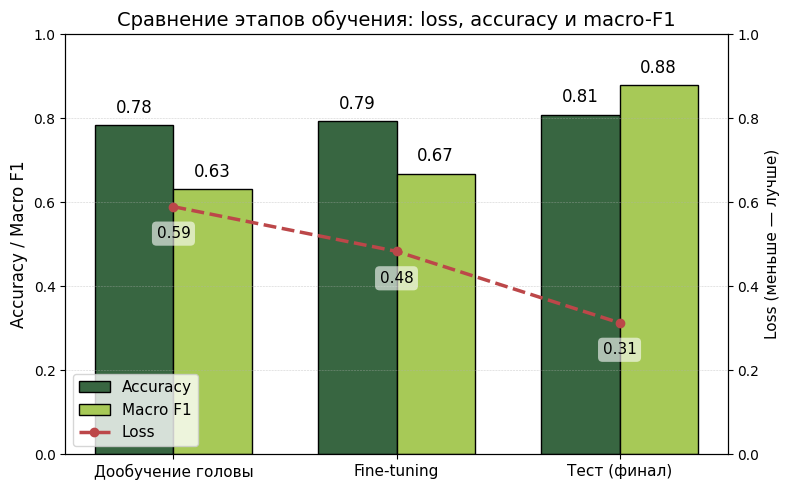

Готово — график сохранён в 'training_results.png'


In [60]:
import matplotlib.pyplot as plt
import numpy as np

# ====== Входные данные ======
stages = ["Дообучение головы", "Fine-tuning", "Тест (финал)"]
loss = [0.5890, 0.4827, 0.3125]
acc  = [0.7837, 0.7933, 0.8077]
f1   = [0.6308, 0.6673, 0.8777]

# ====== Цвета ======
COLOR_ACC = "#386641"   # синий
COLOR_F1  = "#a7c957"   # бирюзовый
COLOR_LOSS = "#bc4749"  # твой выбранный цвет (трендовая линия)

x = np.arange(len(stages))
width = 0.35

fig, ax1 = plt.subplots(figsize=(8, 5))

# === Столбцы для accuracy и F1 ===
bars_acc = ax1.bar(x - width/2, acc, width, label="Accuracy", color=COLOR_ACC, edgecolor="black")
bars_f1  = ax1.bar(x + width/2, f1,  width, label="Macro F1", color=COLOR_F1, edgecolor="black")

ax1.set_ylim(0.0, 1.0)
ax1.set_xticks(x)
ax1.set_xticklabels(stages, fontsize=11)
ax1.set_ylabel("Accuracy / Macro F1", fontsize=12)
ax1.set_title("Сравнение этапов обучения: loss, accuracy и macro-F1", fontsize=14)
ax1.grid(axis="y", linestyle="--", linewidth=0.4, alpha=0.6)

# === Подписи над столбцами ===
def annotate_bars(bars, ax, fmt="{:.2f}"):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(fmt.format(h),
                    xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 6),
                    textcoords="offset points",
                    ha="center", va="bottom", fontsize=12)

annotate_bars(bars_acc, ax1)
annotate_bars(bars_f1, ax1)

# === Линия для loss ===
ax2 = ax1.twinx()
ax2.set_ylim(0, 1)
ax2.plot(x, loss, marker='o', linestyle='--', linewidth=2.5, color=COLOR_LOSS, label="Loss")
ax2.set_ylabel("Loss (меньше — лучше)", fontsize=11)

# === Подписи с полупрозрачным фоном ===
for xi, l in zip(x, loss):
    ax2.annotate(f"{l:.2f}",
                 xy=(xi, l),
                 xytext=(0, -14),
                 textcoords="offset points",
                 ha="center", va="top",
                 fontsize=11,
                 color="black",
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.6, ec="none"))  # фон

# === Легенда ===
lines_labels = ax1.get_legend_handles_labels()
lines_labels2 = ax2.get_legend_handles_labels()
handles = lines_labels[0] + lines_labels2[0]
labels  = lines_labels[1] + lines_labels2[1]
ax1.legend(handles, labels, loc="lower left", fontsize=11)

fig.tight_layout()
out_path = "training_results.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Готово — график сохранён в '{out_path}'")
